deployment helpers

In [1]:
'''
# open through GitHub
# Detect if running in Google Colab
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if in_colab():
    # Only runs in Colab, skipped on local
    # 1. Clone the repo and set paths
    REPO_URL = "https://github.com/MadKeyboardArtist/5703-Federated-Model.git"
    REPO_DIR = "/content/5703-Federated-Model"

    import os, sys
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    os.chdir(REPO_DIR)
    sys.path.append(REPO_DIR)
    print("CWD:", os.getcwd())

    # GPU check
    import torch, subprocess, textwrap
    print("CUDA available:", torch.cuda.is_available())
    !nvidia-smi

    # update the files
    %cd /content/5703-Federated-Model
    !git pull origin main

else:
    print("Running locally — skipping Colab setup.")
'''

'\n# open through GitHub\n# Detect if running in Google Colab\ndef in_colab():\n    try:\n        import google.colab\n        return True\n    except ImportError:\n        return False\n\nif in_colab():\n    # Only runs in Colab, skipped on local\n    # 1. Clone the repo and set paths\n    REPO_URL = "https://github.com/MadKeyboardArtist/5703-Federated-Model.git"\n    REPO_DIR = "/content/5703-Federated-Model"\n\n    import os, sys\n    if not os.path.exists(REPO_DIR):\n        !git clone {REPO_URL}\n    os.chdir(REPO_DIR)\n    sys.path.append(REPO_DIR)\n    print("CWD:", os.getcwd())\n\n    # GPU check\n    import torch, subprocess, textwrap\n    print("CUDA available:", torch.cuda.is_available())\n    !nvidia-smi\n\n    # update the files\n    %cd /content/5703-Federated-Model\n    !git pull origin main\n\nelse:\n    print("Running locally — skipping Colab setup.")\n'

In [2]:
# open through drive
# Detect if running in Google Colab
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if in_colab():
    # mount
    from google.colab import drive
    drive.mount('/content/drive')

    # add path
    import sys
    sys.path.append("/content/drive/MyDrive/5703-Federated-Model")

    # move to correct working directory
    %cd /content/drive/MyDrive/5703-Federated-Model

Mounted at /content/drive
/content/drive/MyDrive/5703-Federated-Model


In [3]:
# initialize model

# Per Round:
# server copies and sends the global model weights.
# client trains locally (on their local dataset).
# client returns its new weights and sample count.
# server aggregates the weights using FedAvg.
# global model is updated.
# (Optional) Evaluate global model on a held-out test set.


# heads record:
# 1. always save the newest
# 2. always save the best ever
# 3. always save curretn best

In [4]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

import all libraries and scripts

In [5]:
# external libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import importlib.util
import json
import shutil
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [6]:
# self-built files

# 1. model structure
from FederatedModel.federated_multihead_model import SharedEncoders, TabularClientModel, ImageClientModel, MultiClientModel
from FederatedModel.model_config import D_TABULAR, D_EMBEDDING, D_FUSION

# 2. site training functions
from SiteTrainingFunctions.tabular_site_training import training as complete_tabular_training
from SiteTrainingFunctions.image_site_training   import training as complete_image_training
# from multi_site_training   import training_loop as multi_training_loop

# 3. aggregration functions
from AggregationFunctions.aggregation_algorithms import aggregate_fedavg  as fedavg
from AggregationFunctions.aggregation_algorithms import aggregate_fedprox as fedprox
from AggregationFunctions.aggregation_algorithms import aggregate_fedadam as fedadam

In [7]:
# reimport some self-built files if any changes
import importlib
import FederatedModel.federated_multihead_model
import SiteTrainingFunctions.tabular_site_training
import SiteTrainingFunctions.image_site_training

importlib.reload(FederatedModel.federated_multihead_model)
importlib.reload(SiteTrainingFunctions.tabular_site_training)
importlib.reload(SiteTrainingFunctions.image_site_training)

<module 'SiteTrainingFunctions.image_site_training' from '/content/drive/MyDrive/5703-Federated-Model/SiteTrainingFunctions/image_site_training.py'>

training configs

In [8]:
# basic confgs initialization
# aggregation config
FED_AVG  = False
FED_PROX = False # NEVER ACTIVE THIS!
# fed_prox need extra steps in site training, which is not implemented
FED_ADAM = False

# task modalities
TABULAR_UPDATE = False
IMAGE_UPDATE   = False
FUSION_UPDATE  = False

# outcomes saving
SAVED_MODELS_FOLDER = "SavedModels"
DATASETS_FOLDER = "Datasets"

helper functions: low-level utility

In [9]:
# ectract weights of the given component in global state dict
def extract_global_components(global_state, prefix):
    # Assume global_state is a full SharedEncoders.state_dict()
    # with keys like "tabular_enc.fc1.weight", "image_enc.conv1.weight", etc.

    enc_state = {
        k: v.clone()
        for k, v in global_state.items()
        if k.startswith(prefix) # keep only parameters start with prefix
    }

    return enc_state

In [10]:
# assign the correct training function to each site
# depends on modality, stored in site info dict
def assign_local_training_function (modality):
    if modality == "tabular":
        return complete_tabular_training
    elif modality == "image":
        return complete_image_training
        # return complete_image_training
    elif modality == "multi":
        pass
    else:
        # report ERROR
        return None

In [11]:
# input file path, return the stored tsfm instance
def load_transform_from_file(tsfm_file_path):
    module_name = os.path.splitext(os.path.basename(tsfm_file_path))[0]
    spec = importlib.util.spec_from_file_location(module_name, tsfm_file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.tsfm  # assumes each .py defines a variable `transform`

In [12]:
# apply the correct aggregation algorithm refer to the congif vars
def aggregation_calculation(global_state, state_list, sample_count_list, server_state):
    if FED_AVG:
        return fedavg (global_state, state_list, sample_count_list, server_state)

    if FED_PROX:
        return fedprox(global_state, state_list, sample_count_list, server_state)

    if FED_ADAM:
        return fedadam(global_state, state_list, sample_count_list, server_state)


In [13]:
# add prefix to keys in component model dict
# preparing for forming the global state dict
def add_prefix_to_enc_dict (prefix, state_dict_list):
    result = []
    for state in state_dict_list:
        # Add the prefix to every key
        enc_with_prefix = {
            f"{prefix}{k}": v.clone() for k, v in state.items()
        }
        result.append(enc_with_prefix)
    return result

In [14]:
# site training
# prepare everything the training function need for running
# return the training returns without any changes

def local_training (global_state, site, freeze_global = False):
    if site["modality"] == "tabular":
        site_name              = site["name"]
        train_set_path         = site["clean_dataset_train"]
        val_set_path           = site["clean_dataset_val"]
        label_col_name         = site["label_col"]
        num_of_classes         = site["n_classes"]
        newest_head_path       = site["newest_head"]
        current_best_head_path = site["current_best_head"]
        freeze_global          = freeze_global

        return site["site_training"](
            site_name              = site_name,
            global_state           = global_state,
            freeze_global          = freeze_global,
            train_set_path         = train_set_path,
            val_set_path           = val_set_path,
            labelcol               = label_col_name,
            n_classes              = num_of_classes,
            newest_head_path       = newest_head_path,
            current_best_head_path = current_best_head_path
            )

    elif site["modality"] == "image":
        site_name              = site["name"]
        train_set_path         = site["clean_dataset_train"]
        val_set_path           = site["clean_dataset_val"]
        site_tsfm              = site["tsfm"]
        num_of_classes         = site["n_classes"]
        newest_head_path       = site["newest_head"]
        current_best_head_path = site["current_best_head"]
        freeze_global          = freeze_global

        return site["site_training"](
            site_name              = site_name,
            global_state           = global_state,
            freeze_global          = freeze_global,
            train_set_path         = train_set_path,
            val_set_path           = val_set_path,
            tsfm                   = site_tsfm,
            n_classes              = num_of_classes,
            newest_head_path       = newest_head_path,
            current_best_head_path = current_best_head_path
            )

    elif site["modality"] == "multi":
        # Not implemented yet
        return None

    else:
        print("site modality error")
        exit()

helper functions: sub-routines

In [15]:
# 1. build local model
# global encoders + local heads

def build_local_head (folder_name, model_name, modality, n_classes):
    # 1. define the complete model structure
    # solved with import

    # 2. assemble local model
    # 2.1 Initialize local encoders
    encoder_placeholder = SharedEncoders(
        d_tabular   = D_TABULAR,
        d_embedding = D_EMBEDDING,
        d_fusion    = D_FUSION
        )
    # 2.2 Load the weights
    # no need here, skip

    # 2.3 build local model
    # modality check
    if modality == "tabular":
        local_model = TabularClientModel(shared_encoders = encoder_placeholder, n_classes = n_classes)
    elif modality == "image":
        local_model = ImageClientModel  (shared_encoders = encoder_placeholder, n_classes = n_classes)
    elif modality == "multi":
        local_model = MultiClientModel  (shared_encoders = encoder_placeholder, n_classes = n_classes)
    else:
        # report ERROR
        exit()

    # 2.4 save the local head weights
    os.makedirs(folder_name, exist_ok = True)
    head_path = os.path.join(folder_name, f"{model_name}.pth")
    torch.save(local_model.head.state_dict(), head_path)
    return head_path

In [16]:
# 2. all sites preparations:
# gather all the necessary infos and functions for each site, store in list of dict

# FOR EACH SITE, to include:
# - all info in the .json
# - tsfm for image site
# - correct training function
# - initialized local models (current_best, overall_best, newest)

def site_preparations (site):
    # 3.1 import all tsfm for image sites
    if site["modality"] == "image":
        # e.g. "Datasets/image_1/image_1_tsmf.py"
        tsfm_path = DATASETS_FOLDER + "/{:s}/{:s}_tsfm.py".format(site["name"], site["name"])
        #full_path = os.path.join("image_dataset_tsfms", tsfm_path)  # subfolder
        full_path = tsfm_path
        site["tsfm"] = load_transform_from_file(full_path)

    # 3.2 initialize local head (only ONCE)
    # file / folder existing: impossible
    # NOT existing: initialize
    model_name  = site["name"]
    modality    = site["modality"]
    n_classes   = site["n_classes"]

    # newest site head (used during training)
    folder_name = SAVED_MODELS_FOLDER + "/newest_local_heads"
    site["newest_head"]       = build_local_head(folder_name, model_name, modality, n_classes)

    # overall best site head (as outcome)
    folder_name = SAVED_MODELS_FOLDER + "/overall_best_local_heads"
    site["overall_best_head"] = build_local_head(folder_name, model_name, modality, n_classes)

    # current best site head (as outcome)
    folder_name = SAVED_MODELS_FOLDER + "/current_best_local_heads"
    site["current_best_head"] = build_local_head(folder_name, model_name, modality, n_classes)

    # 3.3 assign the correct local training function
    site["site_training"] = assign_local_training_function(site["modality"])

    # 3.4 add en empty list for performance track in training
    site["performance_track"] = []

    return site

In [17]:
# 3. one federated learning round
def federated_training_one_round (global_state, sites, freeze_global):
    # 1. sever send global encoder weights to sites
    # by passing global_state

    # 2. full local training
    if freeze_global:
        print("Start head re-training")
    else:
        print("Start site traininig")

    ################ COME TO EACH SITES ##################
    tabular_enc_update = []
    tabular_sample_count = []
    image_enc_update = []
    image_sample_count = []
    fusion_enc_update = []
    fusion_sample_count = []

    all_ckpt_eva_results = []

    for site in sites:
        # full local training
        # using all site info and correct modality training function
        # return valuse:
        # - updated_state: 1 trained encoder state_dict, refer to the site modality
        # - sample_count: trained sample count in this site
        # - ckpt_eva_results: 1 dict, of best performence over epochs
        #   {"val_loss": va_l, "val_acc": va_a, "num_samples": va_sp}
        #   skip for first round training, only returned in head re-training (freeze_global = True)
        # - performance_track: list of acc after each epoch
        #   single round track only

        updated_state, sample_count, ckpt_eva_results, performance_track = local_training(global_state, site, freeze_global)
        ckpt_eva_results["site_name"] = site["name"]
        site["performance_track"].extend(performance_track)

        # record the reaults
        if site["modality"] == "tabular":
            tabular_enc_update.append(updated_state)
            tabular_sample_count.append(sample_count)
        elif site["modality"] == "image":
            image_enc_update.append(updated_state)
            image_sample_count.append(sample_count)
        elif site["modality"] == "multi":
            # fusion and all encoders
            update_tabular_enc = updated_state[0]
            update_image_enc   = updated_state[1]
            update_fusion      = updated_state[2]

            tabular_enc_update.append(update_tabular_enc)
            image_enc_update.append  (update_image_enc)
            fusion_enc_update.append (update_fusion)

            tabular_sample_count.append(sample_count)
            image_sample_count.append  (sample_count)
            fusion_sample_count.append (sample_count)
        # current_best_client_heads.append(best_head_state)
        # newest head, current best head recorded in .pth

        all_ckpt_eva_results.append(ckpt_eva_results)
    ################## END in sites, back to server ##################

    # 4. reutrns all trained global encoders from all sites
    if freeze_global:
        print("Finish head re-training")
    else:
        print("Finish site traininig")

    result = {
        "tabular_update": tabular_enc_update,   # list of model.enc.tabular_enc.state_dict()
        "tabular_count" : tabular_sample_count,
        "image_update"  : image_enc_update,     # list of model.enc.image_enc.state_dict()
        "image_count"   : image_sample_count,
        "fusion_update" : fusion_enc_update,    # list of model.enc.fusion_enc.state_dict()
        "fusion_count"  : fusion_sample_count,
    }

    return result, all_ckpt_eva_results # ((state_dict, int:sample_count), list of dict)

In [18]:
# 4. checkpoint issues
# in global level (macro avg of all sites performance)
# worst guard is applied
# update the ckpt

def federated_ckpt_evaluation (current_results, best_results):
    # traverse through all sites
    new_best_found = False

    # 1. calculate the results
    # macro avg acc only (best for check point)
    current_results_df = pd.DataFrame(current_results)
    macro_acc_current  = current_results_df["val_acc"].mean()
    # weighted_acc = (current_results_df["val_acc"] * current_results_df["num_samples"]).sum() / current_results_df["num_samples"].sum()

    # 2. worst-site guard: Keep it only if no site acc dropped by more than 2 %.
    worst_acc_current = current_results_df["val_acc"].min()

    best_results_df = pd.DataFrame(best_results)
    macro_acc_best  = best_results_df["val_acc"].mean()
    worst_acc_best  = best_results_df["val_acc"].min()

    if macro_acc_current > macro_acc_best and worst_acc_current >= worst_acc_best - 0.02:
        # better macro avg & no sever single drop -> keep the result
        # record best scores
        best_results = current_results # list, not _df
        # tell the caller to save best global model (encoders)
        new_best_found = True
    else:
        # new model is not better
        new_best_found = False

    # 6. return the results
    return new_best_found, best_results

In [19]:
# 5. aggregation calculation
# preparations: to merge inputs to be ready for aggregation calculation
# result reshape: to merge returned calculation results suitable for the following steps

def global_model_aggregation(global_state, update_and_count, server_state=None):

    server_state = server_state or {}

    ## global_updates_with_sample_count = {
    ##   "tabular_update": tabular_enc_update,   # list of model.enc.tabular_enc.state_dict()
    ##   "tabular_count" : tabular_sample_count,
    ##   "image_update"  : image_enc_update,     # list of model.enc.image_enc.state_dict()
    ##   "image_count"   : image_sample_count,
    ##   "fusion_update" : fusion_enc_update,    # list of model.enc.fusion_enc.state_dict()
    ##   "fusion_count"  : fusion_sample_count,
    ## }

    global_tabular = extract_global_components(global_state, "tabular_enc.")
    global_image   = extract_global_components(global_state, "image_enc.")
    global_fusion  = extract_global_components(global_state, "fusion.")

    # 1. tabular enc agg
    if TABULAR_UPDATE:
        tabular_states = update_and_count["tabular_update"]
        tabular_states = add_prefix_to_enc_dict("tabular_enc.", tabular_states)
        tabular_counts = update_and_count["tabular_count"]
        tabular_agg_enc,_ = aggregation_calculation(global_tabular, tabular_states, tabular_counts, server_state)
    else:
        tabular_agg_enc = global_tabular

    # 2. image enc agg
    if IMAGE_UPDATE:
        image_states = update_and_count["image_update"]
        image_states = add_prefix_to_enc_dict("image_enc.", image_states)
        image_counts = update_and_count["image_count"]
        image_agg_enc,_ = aggregation_calculation(global_image, image_states, image_counts, server_state)
    else:
        image_agg_enc = global_image

    # 3. fusion agg
    if FUSION_UPDATE:
        fusion_states = update_and_count["fusion_update"]
        fusion_states = add_prefix_to_enc_dict("fusion.", fusion_states)
        fusion_counts = update_and_count["fusion_count"]
        fusion_agg,_ = aggregation_calculation(global_fusion, fusion_states, fusion_counts, server_state)
    else:
        fusion_agg = global_fusion

    # 4. merge back the global state dict
    agg_global_state = {}
    agg_global_state.update(tabular_agg_enc)
    agg_global_state.update(image_agg_enc)
    agg_global_state.update(fusion_agg)

    return agg_global_state

MAIN PROCESS START

In [20]:
# 0. (BEFORE training) clean all recorded models
# newest local heads
folder_path = SAVED_MODELS_FOLDER + "/newest_local_heads"
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)   # deletes the folder and everything inside
    print(f"Deleted folder: {folder_path}")
else:
    print("Folder does not exist.")

# overall best local heads
folder_path = SAVED_MODELS_FOLDER + "/overall_best_local_heads"
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)   # deletes the folder and everything inside
    print(f"Deleted folder: {folder_path}")
else:
    print("Folder does not exist.")

# current best local heads
folder_path = SAVED_MODELS_FOLDER + "/current_best_local_heads"
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)   # deletes the folder and everything inside
    print(f"Deleted folder: {folder_path}")
else:
    print("Folder does not exist.")

# best global encoders
file_path = SAVED_MODELS_FOLDER + "best_global_encoders.pth"
if os.path.exists(file_path):
    shutil.rmtree(file_path)   # deletes the .pth file
    print(f"Deleted folder: {file_path}")
else:
    print("File does not exist.")

Deleted folder: SavedModels/newest_local_heads
Deleted folder: SavedModels/overall_best_local_heads
Deleted folder: SavedModels/current_best_local_heads
File does not exist.


In [21]:
# 1. initialize global model
global_encoders = SharedEncoders(
    d_tabular   = D_TABULAR,
    d_embedding = D_EMBEDDING,
    d_fusion    = D_FUSION
    )
global_state = global_encoders.state_dict()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s] 


In [22]:
# 2. build sites
# 2.1 run build site info (list of dict)
pass

# 2.2 import all sites (basic info)
with open("sites_info_testing.json", "r") as f:
# with open("sites_info.json", "r") as f:
    sites = json.load(f)

# sites

In [23]:
# 3. all sites preparations:
# FOR EACH SITE:
# 3.1 read in all in .json
# 3.2 run site_preparations for extra items

for site in sites:
    site = site_preparations(site)

# sites

In [24]:
# 4. operate federated training loop
# 4.0 configs
# (MANUALLY) set training rounds
training_round = 5

# (MANUALLY) active the agg alg
FED_AVG  = True
FED_PROX = False # NEVER ACTIVE THIS!
# fed_prox need extra steps IN site training, which is not implemented
FED_ADAM = False

# (AOTU) decide components to update
for site in sites:
    if not TABULAR_UPDATE:
        if site["modality"] == "tabular":
            TABULAR_UPDATE = True
            continue
        else: pass

    if not IMAGE_UPDATE:
        if site["modality"] == "image":
            IMAGE_UPDATE = True
            continue
        else: pass

    if not FUSION_UPDATE:
        if site["modality"] == "multi":
            FUSION_UPDATE = True
            continue
        else: pass

# 4.1 initialization -- best global: save the initial global state as current best
best_global_path = SAVED_MODELS_FOLDER + "/best_global_encoders.pth"
torch.save(global_state, best_global_path)

# 4.2 initialization -- best evaluation scores
best_ckpt_eva_results = [] # list of dict: {"site_name", "val_loss", "val_acc", "num_samples"}
for site in sites:
    results = {
        "site_name": site["name"],
        "val_loss" : float("inf"),
        "val_acc"  : -1.0,
        "num_samples": 0
        }
    best_ckpt_eva_results.append(results)

In [25]:
# 4.3 training
for i in range(training_round):
    print("global update round {:d}:".format(i+1))
    # 1. one federated training round -> ALL sites FULLY trained ONCE
    global_updates_with_sample_count, _ = federated_training_one_round(global_state, sites, freeze_global=False)
    # data structure:
    ## global_updates_with_sample_count = {
    ##   "tabular_update": tabular_enc_update,   # list of model.enc.tabular_enc.state_dict()
    ##   "tabular_count" : tabular_sample_count,
    ##   "image_update"  : image_enc_update,     # list of model.enc.image_enc.state_dict()
    ##   "image_count"   : image_sample_count,
    ##   "fusion_update" : fusion_enc_update,    # list of model.enc.fusion_enc.state_dict()
    ##   "fusion_count"  : fusion_sample_count,
    ## }

    # 2. Server: Global encoder aggregation
    agg_state = global_model_aggregation(global_state, global_updates_with_sample_count)

    '''#========================
    # state shape checking
    print("")
    print("agg state shape checking===================")
    for k, v in agg_state.items():
      if "image_enc.proj" in k:
          print(k, v.shape)
    print("end========================================")
    print("")
    #========================'''

    # 3. (OPTIONAL) head retraining with agg_state
    # freezed global encoders
    # double running time (do 1 samalier training round 2 times: 1 with freezed global encoders, and 1 without)
    # perfect match of global encoders and local heads
    _, current_ckpt_eva_results = federated_training_one_round(agg_state, sites, freeze_global=True)
    # ((state_dict, int:sample_count), list of dict)

    # 4. Evaluation on val set
    new_best_found, best_site_evaluation_results = federated_ckpt_evaluation (current_ckpt_eva_results,
                                                                              best_ckpt_eva_results
                                                                              )
    # best_site_evaluation_results updated by return values

    # 5. record the new model (global + all heads if they are the best)
    # (pravicy issues: server and site should save model components seperately)
    if new_best_found:
        # save the new_global_state to best_global_path
        torch.save(agg_state, best_global_path)
        # call all site to replace the "overall_best_local_heads" with "current_best_local_heads"
        pass
    else: # no changes
        pass

    # 4. start the next round
    global_state = agg_state
    print("")

global update round 1:
Start site traininig
image_1: image site training START
 [best updated] acc: 0.6878
 [best updated] acc: 0.6962
 [best updated] acc: 0.7152
 [best updated] acc: 0.7236
 [best updated] acc: 0.7342
image_1: image site training DONE
tabular_1: tabular site training START
 [best updated] acc: 0.8348
 [best updated] acc: 0.8370
tabular_1: tabular site training DONE
tabular_3: tabular site training START
 [best updated] acc: 0.6398
 [best updated] acc: 0.6655
tabular_3: tabular site training DONE
Finish site traininig
Start head re-training
image_1: image site training START
 [best updated] acc: 0.7236
 [best updated] acc: 0.7257
 [best updated] acc: 0.7194
 [best updated] acc: 0.7257
 [best updated] acc: 0.7278
image_1: image site training DONE
tabular_1: tabular site training START
 [best updated] acc: 0.8365
 [best updated] acc: 0.8368
 [best updated] acc: 0.8369
 [best updated] acc: 0.8369
tabular_1: tabular site training DONE
tabular_3: tabular site training START

In [ ]:
# plt the performance track for all sites
lists = []
plt_title = []
for site in sites:
    performance_track = site["performance_track"]
    lists.append(performance_track)
    plt_title.append(site["name"])

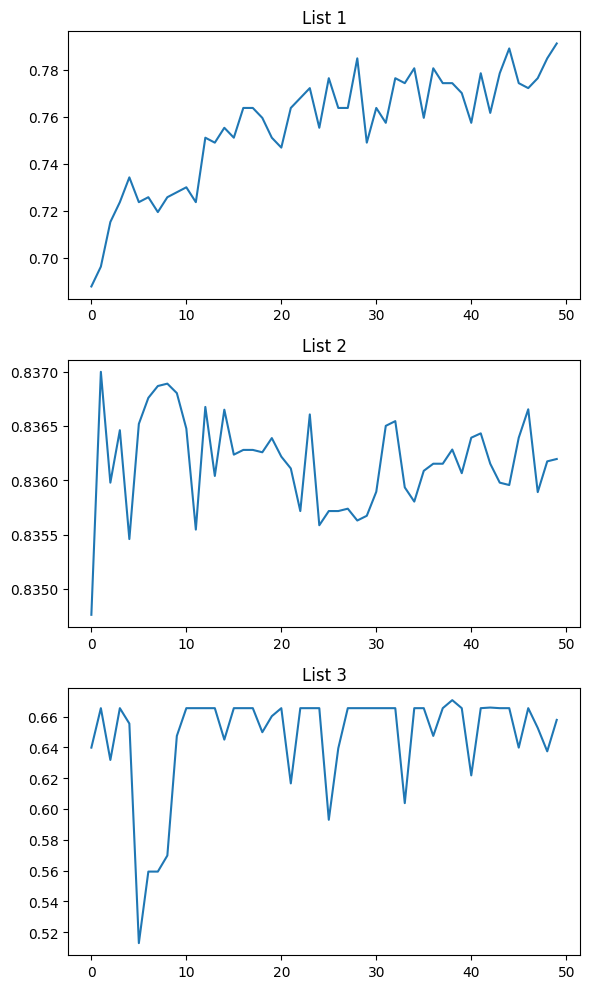

In [27]:
fig, axs = plt.subplots(len(lists), 1, figsize=(6, 10))

for i, arr in enumerate(lists):
    axs[i].plot(arr)
    axs[i].set_title(f"List {i+1}")

plt.tight_layout()
plt.show()

In [31]:
for i in lists:
  print(len(i))

50
50
50
